```text
y_true  y_pred
    0       1
    0       0
    0       0
    0       0
    1       1
    1       0
    1       1
    1       1
    1       1
    1       0
--------------------
    0       1
0   3       1
1   2       4 --> 총 10 정확도 0.7


## confusion matrix:혼동행렬

<img src='https://velog.velcdn.com/images/leehb9360/post/7eb8ca12-94be-40ed-b7a4-b9e9701a93df/image.png'>

| 지표         | 공식                                                         | 의미                                                                 | 값 범위 |
|--------------|--------------------------------------------------------------|----------------------------------------------------------------------|--------|
| 정확도(Accuracy) | $\frac{TP + TN}{TP + TN + FP + FN}$                         | 전체 예측 중 맞춘 비율 (정답률)                                      | 0 ~ 1  |
| 정밀도(Precision) | $\frac{TP}{TP + FP}$                                       | **양성 예측 중** 실제로 양성인 비율 (거짓 양성 줄이기)                | 0 ~ 1  |
| 재현율(Recall)    | $\frac{TP}{TP + FN}$                                       | **실제 양성 중** 맞게 예측한 비율 (거짓 음성 줄이기)                   | 0 ~ 1  |
| F1-score     | $\frac{2 \times Precision \times Recall}{Precision + Recall}$ | Precision과 Recall의 조화 평균 (둘 다 중요할 때 사용)                 | 0 ~ 1  |

> **TP**: True Positive (실제 양성을 맞게 예측)  
> **TN**: True Negative (실제 음성을 맞게 예측)  
> **FP**: False Positive (실제 음성을 양성으로 예측)  
> **FN**: False Negative (실제 양성을 음성으로 예측)


| 지표                  | 쉽게 비유                               | 의미                                 | 계산 공식                                   |
| ------------------- | ----------------------------------- | ---------------------------------- | --------------------------------------- |
| **정밀도** (Precision) | **"내가 합격이라고 한 사람 중에 진짜 합격한 사람 비율"** | 예측을 얼마나 **정확하게 골랐는지**              | $ \frac{TP}{TP + FP} $                |
| **재현율** (Recall)    | **"진짜 합격한 사람 중에 내가 합격이라고 맞춘 비율"**   | 실제 양성을 **얼마나 놓치지 않았는지**            | $ \frac{TP}{TP + FN} $                |
| **F1-score**        | **정밀도와 재현율의 균형 점수**                 | Precision과 Recall이 모두 중요할 때의 성능 지표 | $ \frac{2 \times P \times R}{P + R} $ |


- 정밀도↑ → "맞춘 것만큼은 진짜 맞게" (거짓양성 줄이기)
- 재현율↑ → "놓치지 않고 다 잡기" (거짓음성 줄이기)
- F1-score → 두 가지를 균형 있게 잘하는지 확인



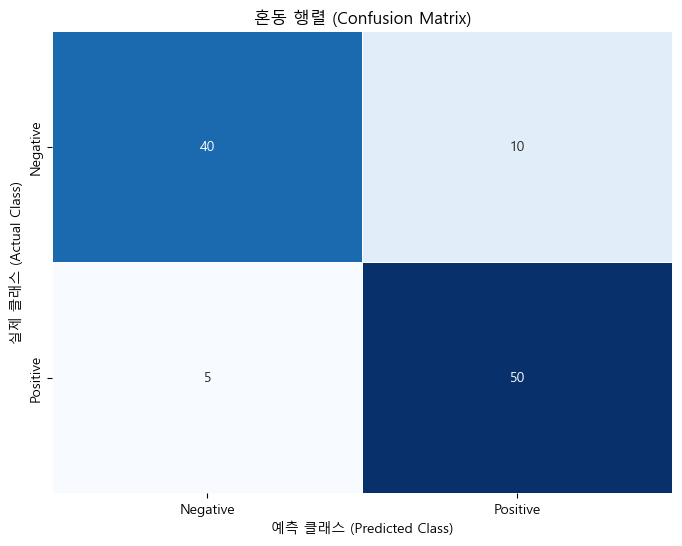

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 혼동 행렬 예시 데이터
TP = 50
TN = 40
FP = 10
FN = 5

# 혼동 행렬(Confusion Matrix) 배열 생성
# 행: 실제 값 (Actual), 열: 예측 값 (Predicted)
# [[TN, FP],
#  [FN, TP]]
cm = np.array([[TN, FP],
               [FN, TP]])

# 클래스 레이블 정의 (예: Negative, Positive)
labels = ['Negative', 'Positive']

# Seaborn을 사용하여 히트맵으로 시각화
plt.figure(figsize=(8, 6))

# annot=True: 셀 안에 값 표시
# fmt='d': 정수 형식으로 표시
# cmap='Blues': 색상 맵 지정
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=labels, yticklabels=labels,
            linewidths=.5, cbar=False) 

# 축 레이블 설정
plt.xlabel('예측 클래스 (Predicted Class)')
plt.ylabel('실제 클래스 (Actual Class)')
plt.title('혼동 행렬 (Confusion Matrix)')

# 시각화된 혼동 행렬 출력
plt.show()


In [10]:
# 혼동 행렬 예시 데이터 (Confusion Matrix Example Data)
TP = 50  # True Positive (실제 양성을 양성으로 맞게 예측)
TN = 40  # True Negative (실제 음성을 음성으로 맞게 예측)
FP = 10  # False Positive (실제 음성을 양성으로 잘못 예측) - 1종 오류
FN = 5   # False Negative (실제 양성을 음성으로 잘못 예측) - 2종 오류

# 총 데이터 수
total = TP + TN + FP + FN

# 1. 정확도 (Accuracy)
# 전체 예측 중 올바르게 예측한 비율: (TP + TN) / Total
accuracy = (TP + TN) / total

# 2. 정밀도 (Precision)
# 양성으로 예측한 것 중 실제 양성인 비율: TP / (TP + FP)
precision = TP / (TP + FP)

# 3. 재현율 (Recall) 또는 민감도 (Sensitivity)
# 실제 양성인 것 중 양성으로 올바르게 예측한 비율: TP / (TP + FN)
recall = TP / (TP + FN)

# 4. F1-score
# 정밀도와 재현율의 조화 평균: 2 * (Precision * Recall) / (Precision + Recall)

f1 = 2 * (precision * recall) / (precision + recall)

# 결과 출력 (Output)
print(f"--- 혼동 행렬 값 ---")
print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
print(f"Total Data: {total}")
print(f"--------------------")
print(f"정확도 (Accuracy): {accuracy:.3f}")
print(f"정밀도 (Precision): {precision:.3f}")
print(f"재현율 (Recall): {recall:.3f}")
print(f"F1-score: {f1:.3f}")


--- 혼동 행렬 값 ---
TP: 50, TN: 40, FP: 10, FN: 5
Total Data: 105
--------------------
정확도 (Accuracy): 0.857
정밀도 (Precision): 0.833
재현율 (Recall): 0.909
F1-score: 0.870



### ✅ 계산 결과

  * **정확도 (Accuracy):** 0.900
    $$(50 + 40) / (50 + 40 + 10 + 5) = 90 / 105 \approx 0.857$$
  * **정밀도 (Precision):** 0.833
    $$50 / (50 + 10) = 50 / 60 \approx 0.833$$
  * **재현율 (Recall):** 0.909
    $$50 / (50 + 5) = 50 / 55 \approx 0.909$$
  * **F1-score:** 0.870
    $$2 \times 0.833 \times 0.909 / (0.833 + 0.909) \approx 0.870$$

-----


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

actual = np.array(["yes", "no", "yes", "yes", "no", "no", "yes", "no", "yes", "no"])
pred = np.array(["yes", "no", "no", "yes", "no", "yes", "yes", "no", "no", "no"])

labels = ["no", "yes"] 
cm = confusion_matrix(actual, pred, labels=labels)

print("1. 혼동 행렬 (Confusion Matrix)")
cm_df = pd.DataFrame(cm, index=['Actual No', 'Actual Yes'], columns=['Pred No', 'Pred Yes'])
print(cm_df)
print('===================')


accuracy = accuracy_score(actual, pred)
precision = precision_score(actual, pred, pos_label="yes")
recall = recall_score(actual, pred, pos_label="yes")
f1= f1_score(actual, pred, pos_label="yes")

print("2. 평가 지표")
print(f"정확도(Accuracy): {accuracy:.3f}")
print(f"정밀도(Precision): {precision:.3f}")
print(f"재현율(Recall): {recall:.3f}")
print(f"F1-score: {f1:.3f}")
print('===================')




1. 혼동 행렬 (Confusion Matrix)
            Pred No  Pred Yes
Actual No         4         1
Actual Yes        2         3
2. 평가 지표
정확도(Accuracy): 0.700
정밀도(Precision): 0.750
재현율(Recall): 0.600
F1-score: 0.667


<img src='https://velog.velcdn.com/images/leehb9360/post/7eb8ca12-94be-40ed-b7a4-b9e9701a93df/image.png'>

### ROC

https://angeloyeo.github.io/2020/08/05/ROC.html

- False Positive Rate(FPR)와 True Positive Rate(TPR)은 ROC curve에서 각각 x, y축에 표시되는 값을 의미.
- FPR과 TPR 모두 Positive라는 공통적인 단어가 있음.
- “Positive”의 의미는 판단자가 “그렇다”라고 판별했다는 의미.
- 가령 병원에 환자가 암 검사를 받기 위해 내원했고, 의사(즉, 여기서 판단자)가 “환자가 암에 걸렸다”라고 판단한 것.
- 그렇다면 True와 False는 무슨 의미일까?
- True와 False는 각각 ‘판단을 올바르게 했다’는 것과 ‘판단을 틀리게 했다’는 것을 표현한다.
- True Positive는 실제로 이 사람은 암에 걸려있고, 판단을 암에 걸렸다고 판단한 것이며, 
- False Positive는 실제로는 암에 걸리지 않았는데도 암에 걸렸다고 ‘잘못’ 판단한 것을 의미한다.

<img src='https://raw.githubusercontent.com/angeloyeo/angeloyeo.github.io/master/pics/2020-08-05-ROC/pic3.png'>

<img src='https://raw.githubusercontent.com/angeloyeo/angeloyeo.github.io/master/pics/2020-08-05-ROC/pic4.gif'>


<img src='https://raw.githubusercontent.com/angeloyeo/angeloyeo.github.io/master/pics/2020-08-05-ROC/pic5.gif'>


- threshold 설정에 따른 변화

<img src='https://raw.githubusercontent.com/angeloyeo/angeloyeo.github.io/master/pics/2020-08-05-ROC/pic6.gif'>

- 두 클래스를 더 잘 구별할 수 있다면 ROC 커브는 좌상단에 더 가까워지게 된다

<img src='https://raw.githubusercontent.com/angeloyeo/angeloyeo.github.io/master/pics/2020-08-05-ROC/pic7.gif'>

ROC(Receiver Operating Characteristic) 곡선이 좌상단 모서리($\text{0, 1}$)에 가까워질수록 두 클래스(예: 양성/음성, 질병 유무)를 **더 잘 구별**할 수 있게 되는 이유

###  핵심 요약

ROC 곡선이 좌상단에 가까워진다는 것은 **실제 양성을 잘 맞추면서(높은 민감도)**, 동시에 **실제 음성을 잘못 판단하는 경우(낮은 위양성률)**가 줄어든다는 의미입니다. 즉, 분류 모델의 **성능이 좋다**는 뜻입니다.

---

###  ROC 곡선의 두 축

ROC 곡선은 다양한 **분류 임계값(Threshold)**에 따라 모델의 성능이 어떻게 달라지는지를 시각화한 그래프입니다.

* **X축: 위양성률 (False Positive Rate, FPR)**
    * **정의:** 실제로는 **음성(Negative)**인데, 모델이 **양성(Positive)**으로 잘못 예측하는 비율.
    * **계산:** $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$
    * **이상적인 값:** **0**에 가까울수록 좋습니다. (좌측으로 이동)

* **Y축: 민감도 (Sensitivity) 또는 참양성률 (True Positive Rate, TPR)**
    * **정의:** 실제 **양성(Positive)**인 경우를 모델이 **양성(Positive)**으로 정확하게 예측하는 비율.
    * **계산:** $\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}$
    * **이상적인 값:** **1**에 가까울수록 좋습니다. (상단으로 이동)



###  좌상단 ($\text{0, 1}$)의 의미

좌상단 모서리($\text{FPR}=0, \text{TPR}=1$)는 다음을 의미합니다.

| 위치 | X축 (FPR) | Y축 (TPR) | 설명 | 결과 |
| :--- | :---: | :---: | :--- | :--- |
| **좌상단** | **0** (최소) | **1** (최대) | **위양성(FP)이 없고**, **참양성(TP)은 모두** 맞춘 경우 | **완벽한 분류** |

1.  **좌측으로 이동 (FPR $\rightarrow 0$):**
    * 실제 음성인 사람을 양성으로 **잘못 판단하는 실수(FP)**가 거의 없다는 의미입니다. (오진이 적음)

2.  **상단으로 이동 (TPR $\rightarrow 1$):**
    * 실제 양성인 사람을 양성으로 **정확하게 판단(TP)**하는 비율이 매우 높다는 의미입니다. (정답을 잘 맞춤)

따라서, 곡선이 좌상단에 가까울수록 모델은 **'양성'과 '음성' 데이터를 거의 완벽하게 구별**해내고 있다는 뜻이 됩니다. 이는 **분류 성능이 뛰어나다**는 것을 시각적으로 보여주는 것입니다.

| 개념                         | 쉽게 비유                               | 의미                                                                              |
| -------------------------- | ----------------------------------- | ------------------------------------------------------------------------------- |
| **ROC 커브**                 | **"탐지기의 민감도와 거짓경보 비율의 관계를 보는 그래프"** | 분류 모델이 임계값(Threshold)을 바꿨을 때 \*\*민감도(재현율)\*\*와 \*\*거짓양성률(FPR)\*\*이 어떻게 변하는지 시각화 |
| **AUC** (Area Under Curve) | **"ROC 커브 아래 면적"**                  | 1에 가까울수록 모델이 잘 구분함                                                              |


예시 — "금속탐지기"
- 금속탐지기의 **임계값(Threshold)**을 높이면 → 거짓경보(FP)는 줄지만, 진짜 금속(TP)도 놓칠 수 있음 (재현율↓)
- 임계값을 낮추면 → 진짜 금속은 잘 잡지만(재현율↑), 거짓경보도 늘어남(FPR↑)
- ROC 커브는 이 균형의 변화를 보여주는 그래프

 ROC 커브의 축
x축(FPR): 거짓 양성 비율 = $\frac{FP}{FP + TN}$
→ "실제 음성인데 양성이라고 잘못 판단한 비율"

y축(TPR): 재현율(Recall) = $\frac{TP}{TP + FN}$
→ "실제 양성 중 맞게 맞춘 비율"


AUC 해석
- AUC = 1.0 → 완벽한 모델 (한 점에서 TPR=1, FPR=0)
- AUC = 0.5 → 동전 던지기 수준 (모델이 구분 못 함)
- AUC < 0.5 → 오히려 반대로 예측하는 모델 (뒤집으면 성능 향상 가능)

actual_bin [1 0 1 1 0 0 1 0 1 0]
pred_bin [1 0 0 1 0 1 1 0 0 0]
3. ROC 커브 & AUC
AUC: 0.700


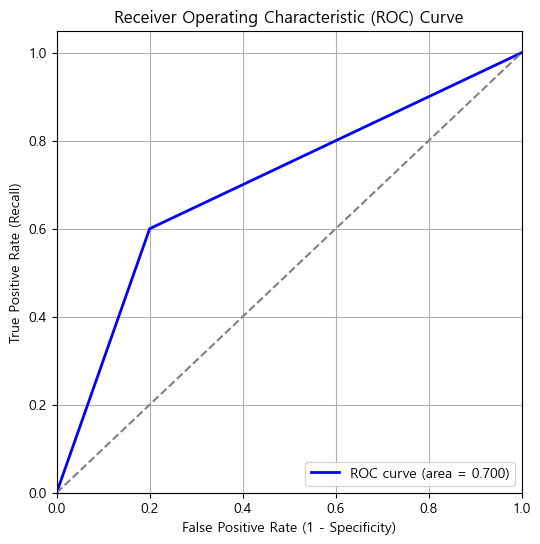

In [12]:

# 3. ROC 커브 & AUC

# ROC 커브를 그리기 위해서는 실제 값(0/1)과 확률 예측 값(0~1)이 필요합니다.
# 하지만 R 코드와 동일하게, 여기서는 이진 예측 값(0/1)을 사용하여 ROC를 계산합니다.
# (Note: 확률을 사용하는 것이 표준입니다.)

# 'yes'를 1, 'no'를 0으로 변환
actual_bin = (actual == "yes").astype(int)
# pred_bin은 확률 대신 이진 예측 값 (0 또는 1)
pred_bin  = (pred == "yes").astype(int) 
print('actual_bin', actual_bin)
print('pred_bin', pred_bin)

# fpr (False Positive Rate), tpr (True Positive Rate), thresholds 계산
fpr, tpr, thresholds = roc_curve(actual_bin, pred_bin)
auc_val = auc(fpr, tpr)

print("3. ROC 커브 & AUC")
print(f"AUC: {auc_val:.3f}")

# ROC Curve 시각화
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # 대각선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show() # 

1. AUC (Area Under the Curve):
AUC: 1.0000
2. ROC 커브 시각화


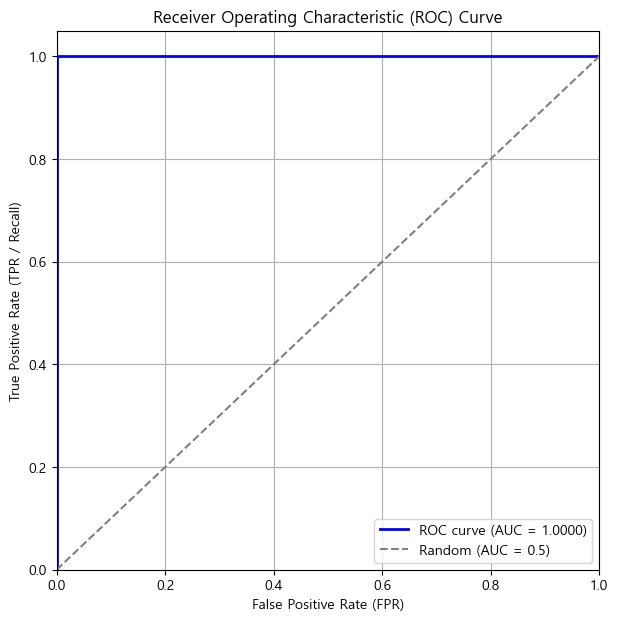

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 데이터 (R 코드와 동일)

# 실제 값 (y_true)
# 1=양성(Positive), 0=음성(Negative)
actual = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])

# 모델이 예측한 확률값 (y_score)
pred_prob = np.array([0.9, 0.1, 0.8, 0.7, 0.4, 0.3, 0.85, 0.2, 0.65, 0.1])


# 2. ROC 커브 데이터 계산 및 AUC 측정

# roc_curve 함수를 사용하여 FPR, TPR, 임곗값(Thresholds) 계산
# FPR: False Positive Rate (X축)
# TPR: True Positive Rate (Y축, Recall)
fpr, tpr, thresholds = roc_curve(actual, pred_prob)

# 계산된 FPR과 TPR을 사용하여 AUC (Area Under the Curve) 계산
auc_val = auc(fpr, tpr)

print("1. AUC (Area Under the Curve):")
print(f"AUC: {auc_val:.4f}")
print("=============================")


# 3. ROC 커브 시각화 (R의 plot(roc_obj) 해당)

print("2. ROC 커브 시각화")
plt.figure(figsize=(7, 7))

# ROC 커브 그리기
plt.plot(fpr, tpr, color='blue', lw=2, 
         label=f'ROC curve (AUC = {auc_val:.4f})')

# 대각선 (랜덤 모델)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

# 그래프 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()